<a href="https://colab.research.google.com/github/yadavrishikesh/Deep-Learning-Slides-Code/blob/main/code/CNN/CNN_RGBImage_CIFAR10_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN for RGB Images (3 Channels) — CIFAR-10

We now move from grayscale images (1 channel) to RGB images (3 channels).

Channels:

- Red
- Green
- Blue

RGB image shape: (height, width, channels) for example (32 × 32 × 3)

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR10 Dataset (RGB images)

This dataset contains:

- airplanes
- cars
- birds
- cats
- deer
- dogs
- frogs
- horses
- ships
- trucks

In [17]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


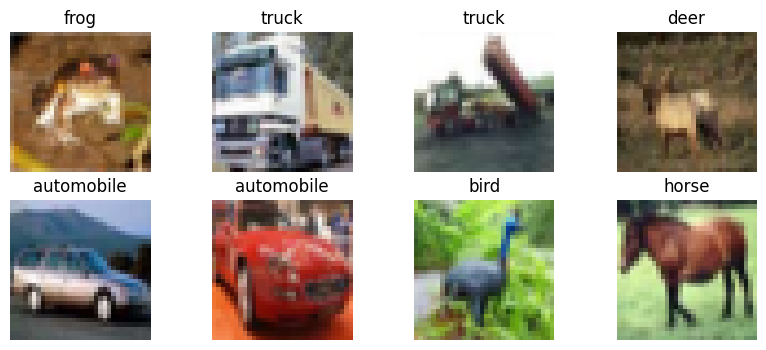

In [18]:
class_names = [
'airplane',
'automobile',
'bird',
'cat',
'deer',
'dog',
'frog',
'horse',
'ship',
'truck'
]
plt.figure(figsize=(10,4))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

## Step 1: Normalize Data

In [19]:
x_train = x_train / 255.0
x_test  = x_test / 255.0

## Step 2: Build CNN for RGB Images

In [20]:
model = keras.Sequential([

    # Conv layer 1
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.MaxPooling2D((2,2)),

    # Conv layer 2
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    # Conv layer 3
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

# Step 3: Comple model

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Step 4: Train model

In [22]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 45ms/step - accuracy: 0.4389 - loss: 1.5431 - val_accuracy: 0.5620 - val_loss: 1.2231
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.5850 - loss: 1.1709 - val_accuracy: 0.5980 - val_loss: 1.1242
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.6433 - loss: 1.0141 - val_accuracy: 0.6408 - val_loss: 1.0196
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.6786 - loss: 0.9097 - val_accuracy: 0.6900 - val_loss: 0.8946
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.7107 - loss: 0.8305 - val_accuracy: 0.7030 - val_loss: 0.8562


## Step 5: Test Accuracy

In [23]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6820 - loss: 0.8996
Test accuracy: 0.6819999814033508


## Step 6: Prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


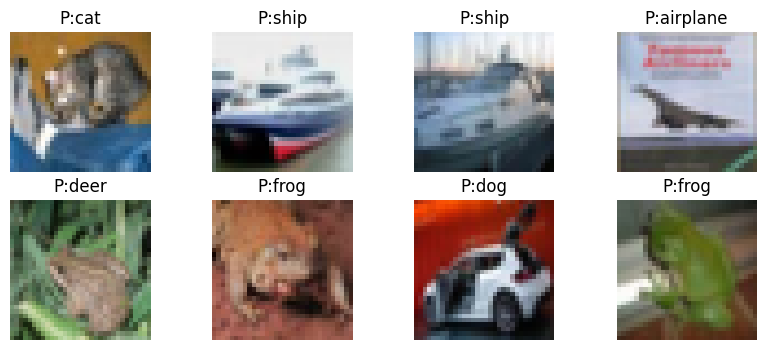

In [24]:
predictions = model.predict(x_test)
plt.figure(figsize=(10,4))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(x_test[i])

    pred = np.argmax(predictions[i])

    true = y_test[i][0]

    plt.title(f"P:{class_names[pred]}")

    plt.axis('off')

plt.show()